4-Qubit Controlled-U Circuit:



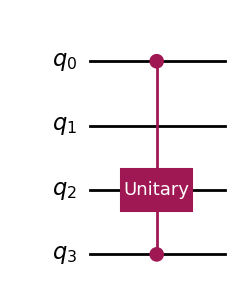


Input State:



<IPython.core.display.Latex object>


Output State:



<IPython.core.display.Latex object>


Full Operator Matrix:



<IPython.core.display.Latex object>

In [ ]:
# ============================================================
# 4-QUBIT: Controlled-U on qubit 3 by qubits 1 and 4
# ============================================================
from qiskit import QuantumRegister, QuantumCircuit
from numpy import pi
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate #to use the func unitarygate
from numpy import pi, cos, sin, exp

# =======================
# Create 4-qubit register
# =======================
q = QuantumRegister(4, 'q')
qc = QuantumCircuit(q)

# ============================================================
# Define ANY single-qubit unitary U
# (Example: U3-type general unitary)
# ============================================================

theta = pi/3
phi = pi/4
lam = pi/5

U = Operator([
    [cos(theta/2), -exp(1j*lam)*sin(theta/2)],
    [exp(1j*phi)*sin(theta/2), exp(1j*(phi+lam))*cos(theta/2)]
])

# ============================================================
# Make it controlled by TWO qubits
# ============================================================

# Convert Operator → Gate
U_gate = UnitaryGate(U)

# Create controlled version (2 controls)
CU = U_gate.control(2)

# Apply:
# controls → q[0], q[3]
# target   → q[2]

qc.append(CU, [q[0], q[3], q[2]])

# ============================================================
# Show circuit
# ============================================================

print("4-Qubit Controlled-U Circuit:\n")
display(qc.draw(output='mpl'))

# ============================================================
# Input state (example)
# ============================================================

# Choose a state where controls = 1 → operation triggers
sv_in = Statevector.from_label("1011")  
# (q3 q2 q1 q0) → be mindful of ordering

print("\nInput State:\n")
display(sv_in.draw("latex"))

# ============================================================
# Output state
# ============================================================

sv_out = sv_in.evolve(qc)

print("\nOutput State:\n")
display(sv_out.draw("latex"))

# ============================================================
# Matrix form (optional, 16×16)
# ============================================================

print("\nFull Operator Matrix:\n")
display(Operator(qc).draw("latex"))